Silhouette Score: 0.44237257041388633


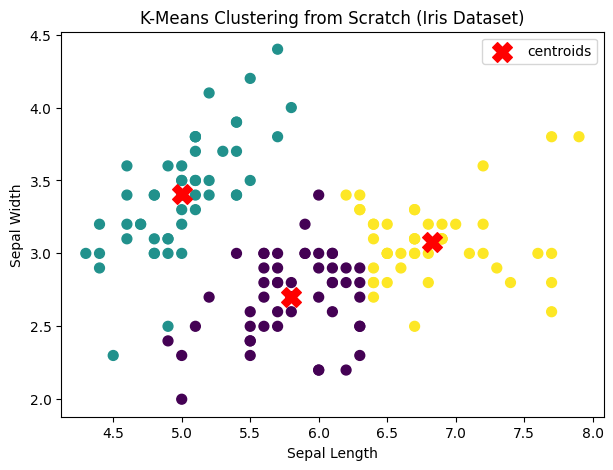

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.metrics import silhouette_score

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Using X for consistency
y = iris.target

class KMeansScratch:
    def __init__(self, k=3, max_iters=100):
        self.k = k
        self.max_iters = max_iters
        self.centroids = None
        self.labels = None

    def fit(self, X):
        np.random.seed(42)
        random_idx = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            self.labels = self.assign_clusters(X)
            new_centroids = self.calculate_centroids(X)

            if np.all(self.centroids == new_centroids):
                break
            self.centroids = new_centroids

    def assign_clusters(self, X):
        distances = np.zeros((X.shape[0], self.k))
        for i, centroid in enumerate(self.centroids):
            distances[:, i] = np.linalg.norm(X - centroid, axis=1)
        return np.argmin(distances, axis=1)

    def calculate_centroids(self, X):
        centroids = []
        for i in range(self.k):
            points = X[self.labels == i]
            if len(points) > 0:
                centroids.append(points.mean(axis=0))
            else:
                centroids.append(self.centroids[i])
        return np.array(centroids)

    def predict(self, X):
        return self.assign_clusters(X)

# Run model
kmeans = KMeansScratch(k=3)
kmeans.fit(X)
labels = kmeans.predict(X)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
            c='red', marker='X', s=200, label="centroids")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering from Scratch (Iris Dataset)")
plt.legend()
plt.show()